In [15]:
import os
import pandas as pd
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import time
import matplotlib.pyplot as plt

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv(dotenv_path="../.env")

os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN", "")

df_full = pd.read_parquet("hf://datasets/19kmunz/iot-23-preprocessed/data/train-00000-of-00001-ad1ef30cd88c8d29.parquet")

df_full['label'] = (df_full['label'] == 'Malicious').astype(int)

print("Class distribution in full dataset:")
print(df_full['label'].value_counts())

sample_size = 250000

df_benign = df_full[df_full['label'] == 0].sample(n=sample_size, random_state=42)
df_malicious = df_full[df_full['label'] == 1].sample(n=sample_size, random_state=42)

df_balanced = pd.concat([df_benign, df_malicious]).sample(frac=1, random_state=42)
df = df_balanced.copy()

print(f"\nBalanced dataset size: {len(df):,}")
print(df['label'].value_counts())


In [17]:

categorical_columns = ['proto', 'service', 'conn_state']
numerical_columns = ['orig_bytes', 'resp_bytes', 'duration', 'orig_pkts', 'resp_pkts', 'missed_bytes']

for col in categorical_columns:
    df[col] = df[col].fillna('Unknown')

for col in numerical_columns:
    df[col] = df[col].fillna(-1)

scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

print(f"Categorical features ({len(categorical_columns)}): {categorical_columns}")
print(f"Numerical features ({len(numerical_columns)}): {numerical_columns}")
print(f"\nTotal features: {len(categorical_columns) + len(numerical_columns)}")

Categorical features (3): ['proto', 'service', 'conn_state']
Numerical features (6): ['orig_bytes', 'resp_bytes', 'duration', 'orig_pkts', 'resp_pkts', 'missed_bytes']

Total features: 9


In [18]:
def train_xgboost_baseline(df, categorical_columns, numerical_columns):
    X = df[categorical_columns + numerical_columns].copy()
    y = df['label'].values
    
    
    label_encoders = {}
    for col in categorical_columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le
    
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)
    
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'max_depth': 6,
        'eta': 0.05,  # Learning rate
        'subsample': 0.8,
        'colsample_bytree': 0.9,
        'min_child_weight': 1,
        'seed': 42,
        'tree_method': 'hist',  # Fast histogram-based method
        'verbosity': 1
    }
    
    
    evallist = [(dtrain, 'train'), (dtest, 'eval')]
    
    evals_result = {}
    
    print("Training XGBoost...")
    start = time.time()
    
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=100,
        evals=evallist,
        evals_result=evals_result,
        early_stopping_rounds=10,
        verbose_eval=10  # Print every 10 rounds
    )
    
    train_time = time.time() - start
    
    y_pred_train = (model.predict(dtrain) > 0.5).astype(int)
    y_pred_test = (model.predict(dtest) > 0.5).astype(int)
    
    train_acc = (y_pred_train == y_train).mean()
    test_acc = (y_pred_test == y_test).mean()
    
    print(f"\n{'='*50}")
    print(f"XGBoost Results:")
    print(f"{'='*50}")
    print(f"Training time: {train_time:.2f} seconds")
    print(f"Training accuracy: {train_acc:.4f}")
    print(f"Test accuracy: {test_acc:.4f}")
    print(f"Best iteration: {model.best_iteration}")
    
    return model, train_acc, test_acc, label_encoders, evals_result, dtest, X_test.index


In [19]:
xgb_model, xgb_train_acc, xgb_test_acc, encoders, evals_result, dtest, test_idx = train_xgboost_baseline(
    df, categorical_columns, numerical_columns
)


Training XGBoost...
[0]	train-logloss:0.64992	eval-logloss:0.64993
[10]	train-logloss:0.40406	eval-logloss:0.40406
[20]	train-logloss:0.27147	eval-logloss:0.27151
[30]	train-logloss:0.20007	eval-logloss:0.20013
[40]	train-logloss:0.15969	eval-logloss:0.15974
[50]	train-logloss:0.13634	eval-logloss:0.13636
[60]	train-logloss:0.12566	eval-logloss:0.12566
[70]	train-logloss:0.11654	eval-logloss:0.11652
[80]	train-logloss:0.11087	eval-logloss:0.11083
[90]	train-logloss:0.10775	eval-logloss:0.10768
[99]	train-logloss:0.10618	eval-logloss:0.10610

XGBoost Results:
Training time: 1.18 seconds
Training accuracy: 0.9675
Test accuracy: 0.9673
Best iteration: 99


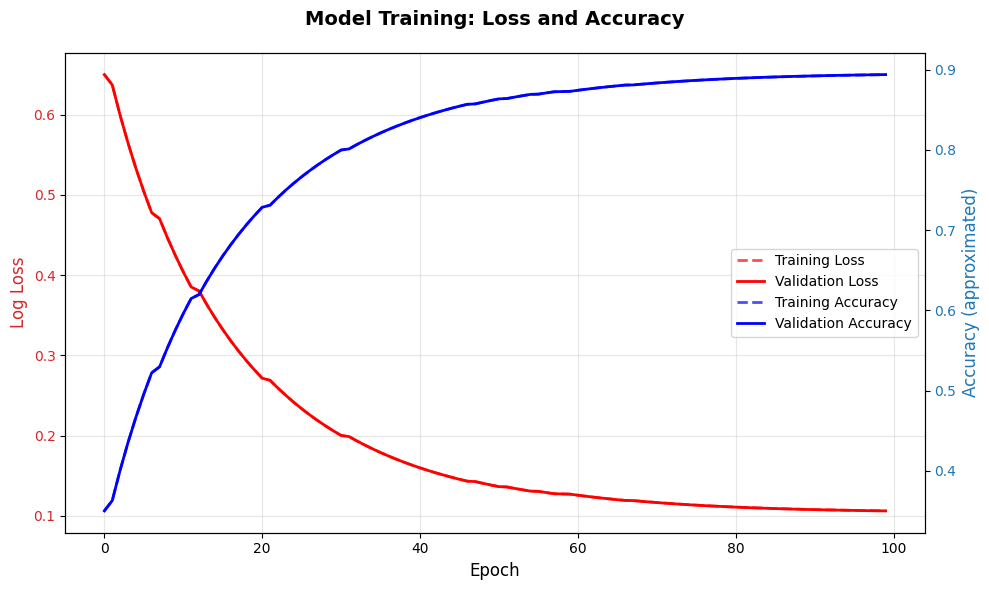


Final Training Loss: 0.1062
Final Validation Loss: 0.1061
Final Training Accuracy: 0.9675
Final Validation Accuracy: 0.9673


In [20]:
fig, ax1 = plt.subplots(figsize=(10, 6))

epochs = range(len(evals_result['train']['logloss']))

color_loss = 'tab:red'
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Log Loss', color=color_loss, fontsize=12)
ax1.plot(epochs, evals_result['train']['logloss'], 'r--', label='Training Loss', linewidth=2, alpha=0.7)
ax1.plot(epochs, evals_result['eval']['logloss'], 'r-', label='Validation Loss', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_loss)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color_acc = 'tab:blue'
ax2.set_ylabel('Accuracy (approximated)', color=color_acc, fontsize=12)

train_acc_history = [1 - loss for loss in evals_result['train']['logloss']]
val_acc_history = [1 - loss for loss in evals_result['eval']['logloss']]

ax2.plot(epochs, train_acc_history, 'b--', label='Training Accuracy', linewidth=2, alpha=0.7)
ax2.plot(epochs, val_acc_history, 'b-', label='Validation Accuracy', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color_acc)

plt.title('Model Training: Loss and Accuracy', fontsize=14, fontweight='bold', pad=20)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=10)

fig.tight_layout()
plt.show()

print(f"\nFinal Training Loss: {evals_result['train']['logloss'][-1]:.4f}")
print(f"Final Validation Loss: {evals_result['eval']['logloss'][-1]:.4f}")
print(f"Final Training Accuracy: {xgb_train_acc:.4f}")
print(f"Final Validation Accuracy: {xgb_test_acc:.4f}")

In [21]:

# loads the gemini api key from the .env file and initializes the client

import sys
import subprocess
# subprocess.run([sys.executable, "-m", "pip", "install", "google-genai", "python-dotenv", "-q"])

import os
from google import genai
from dotenv import load_dotenv

load_dotenv()

client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))
print("gemini is ready")


gemini is ready


In [22]:

# uses the test set from training (returned above) to get prediction confidence scores,
# then attaches them to the original unscaled rows so gemini gets readable values.

probs = xgb_model.predict(dtest)
preds = (probs > 0.5).astype(int)

original_test = df.loc[test_idx].copy()
original_test['predicted'] = preds
original_test['confidence'] = probs

caught_malicious = original_test[(original_test['label'] == 1) & (original_test['predicted'] == 1)]

print(f"correctly flagged malicious samples: {len(caught_malicious):,}")


correctly flagged malicious samples: 49,463


In [23]:
probs = xgb_model.predict(dtest)
preds = (probs > 0.5).astype(int)

original_test = df.loc[test_idx].copy()
original_test['predicted'] = preds
original_test['confidence'] = probs

malicious = original_test[(original_test['label'] == 1) & (original_test['predicted'] == 1)]

print(malicious[['proto', 'service', 'conn_state']].value_counts().head(20))


proto  service  conn_state
tcp    Unknown  S0            43215
                OTH            5955
       irc      S3              129
       Unknown  REJ             121
                SF               17
       http     SF               10
       irc      RSTR              7
       Unknown  RSTR              6
                S1                1
       irc      SF                1
       ssh      SF                1
Name: count, dtype: int64


In [24]:

# picks up to 5 representative samples to send to gemini. groups by traffic profile
# (protocol, service, connection state) and takes the highest confidence one from each
# group so we get variety instead of 5 nearly identical samples.

sorted_malicious = caught_malicious.sort_values('confidence', ascending=False)
diverse_samples = sorted_malicious.groupby(['proto', 'service', 'conn_state'], observed=True).first().reset_index().head(5)

print(diverse_samples[['proto', 'service', 'conn_state', 'confidence']])


  proto  service conn_state  confidence
0   tcp  Unknown        OTH    0.995446
1   tcp  Unknown        REJ    0.958781
2   tcp  Unknown       RSTR    0.943831
3   tcp  Unknown         S0    0.996968
4   tcp  Unknown         S1    0.769158


In [25]:

# sends each traffic profile to gemini with the raw feature values and asks it to explain
# what the attack likely is, why its dangerous, how severe it is, and how to stop it.
# prints each response as it comes in and stores everything in gemini_results.

import json

def ask_gemini(row):
    prompt = f"""
You are a cybersecurity analyst reviewing flagged IoT network traffic.
An XGBoost model classified this flow as malicious with {row['confidence']*100:.1f}% confidence.

Flow details:
- proto: {row['proto']}, service: {row['service']}, conn_state: {row['conn_state']}
- orig_bytes: {row['orig_bytes']:.0f}, resp_bytes: {row['resp_bytes']:.0f}
- duration: {row['duration']:.4f}s, orig_pkts: {row['orig_pkts']:.0f}, resp_pkts: {row['resp_pkts']:.0f}
- missed_bytes: {row['missed_bytes']:.0f}

Respond ONLY with a JSON object using this exact structure, no extra text:
{{
  "attack_type": "short name of the most likely attack",
  "severity": <1-5 rating of how dangerous this is>,
  "summary": "1-2 sentence technical summary of what happened",
  "key_indicators": ["indicator 1", "indicator 2"],
  "impact": "brief description of potential damage",
  "affected_devices": ["device type 1", "device type 2"],
  "mitigations": ["action 1", "action 2", "action 3"],
  "log_signatures": ["pattern to look for 1", "pattern 2"]
}}
"""
    raw = client.models.generate_content(model="gemini-2.5-flash", contents=prompt).text
    cleaned = raw.strip().removeprefix("```json").removeprefix("```").removesuffix("```").strip()
    return json.loads(cleaned)


gemini_results = []

row = diverse_samples.iloc[0]
print(f"proto: {row['proto']} | service: {row['service']} | conn_state: {row['conn_state']}")
analysis = ask_gemini(row)
print(json.dumps(analysis, indent=2))
gemini_results.append({"proto": row['proto'], "service": row['service'], "conn_state": row['conn_state'], "confidence": row['confidence'], "analysis": analysis})


proto: tcp | service: Unknown | conn_state: OTH
{
  "attack_type": "Malformed Packet Attack",
  "severity": 5,
  "summary": "A highly malformed TCP connection attempt was detected, exhibiting impossible negative values for duration, byte counts, and packet counts, alongside an unknown service and an abnormal connection state (OTH). This strongly indicates a severe protocol anomaly or an exploit attempt.",
  "key_indicators": [
    "Negative duration, orig_bytes, resp_bytes, orig_pkts, resp_pkts, missed_bytes",
    "conn_state: OTH (Other/No Connection)",
    "service: Unknown"
  ],
  "impact": "Could lead to device instability, Denial of Service (DoS), system crashes, or indicate an advanced exploitation attempt designed to bypass security controls or corrupt logging. Potential for complete device compromise or unauthorized network access.",
  "affected_devices": [
    "IoT Devices",
    "Embedded Systems",
    "Network Devices"
  ],
  "mitigations": [
    "Deploy deep packet inspectio

In [26]:

# saves all the gemini responses to a text file so you don't have to re-run the api calls every time

with open("gemini_analysis_report.txt", "w", encoding="utf-8") as f:
    for i, r in enumerate(gemini_results, 1):
        f.write(f"sample {i}: {r['proto']} | {r['service']} | {r['conn_state']} | {r['confidence']*100:.1f}% confidence\n")
        f.write(json.dumps(r['analysis'], indent=2))
        f.write("\n\n")

print("saved to gemini_analysis_report.txt")


saved to gemini_analysis_report.txt


In [27]:

# saves the trained model, scaler, and encoders so the FastAPI backend can load them
# run this cell after training to generate the files the backend needs

import joblib
import os

save_dir = "backend"
os.makedirs(save_dir, exist_ok=True)

xgb_model.save_model(os.path.join(save_dir, "xgb_model.ubj"))
joblib.dump(scaler, os.path.join(save_dir, "scaler.pkl"))
joblib.dump(encoders, os.path.join(save_dir, "encoders.pkl"))

print("saved model artifacts to backend/")
print(f"  - xgb_model.ubj")
print(f"  - scaler.pkl")
print(f"  - encoders.pkl")


saved model artifacts to backend/
  - xgb_model.ubj
  - scaler.pkl
  - encoders.pkl


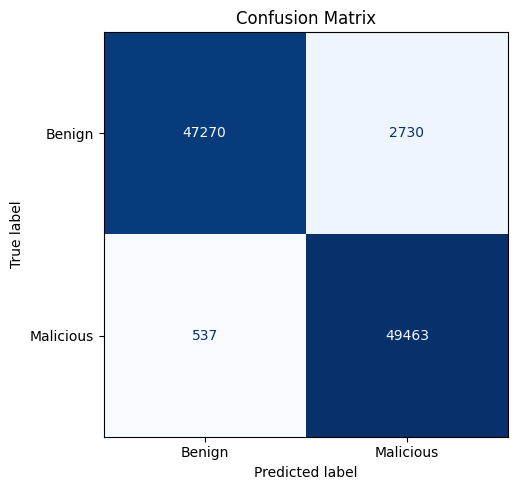

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_test = dtest.get_label().astype(int)
y_pred_test = (xgb_model.predict(dtest) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malicious'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


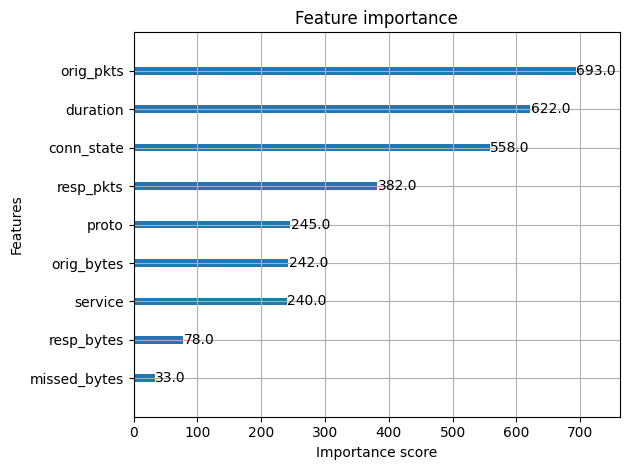

In [29]:
xgb.plot_importance(xgb_model, max_num_features=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()


## Severity Classification Clustering Attempt

In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# run clustering on the malicious flows only
malicious_features = malicious[categorical_columns + numerical_columns].copy()

# label encode for clustering
from sklearn.preprocessing import LabelEncoder
for col in categorical_columns:
    le = LabelEncoder()
    malicious_features[col] = le.fit_transform(malicious_features[col].astype(str))

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(malicious_features)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(malicious_features, labels, sample_size=5000, random_state=42))
    print(f"k={k}  inertia={km.inertia_:.0f}  silhouette={silhouette_scores[-1]:.4f}")


k=2  inertia=21132  silhouette=0.9902
k=3  inertia=7054  silhouette=0.9902
k=4  inertia=2050  silhouette=0.9902
k=5  inertia=864  silhouette=0.9944
k=6  inertia=252  silhouette=0.9944
k=7  inertia=131  silhouette=0.9942
k=8  inertia=52  silhouette=0.9946
k=9  inertia=19  silhouette=0.9950
k=10  inertia=13  silhouette=0.9950


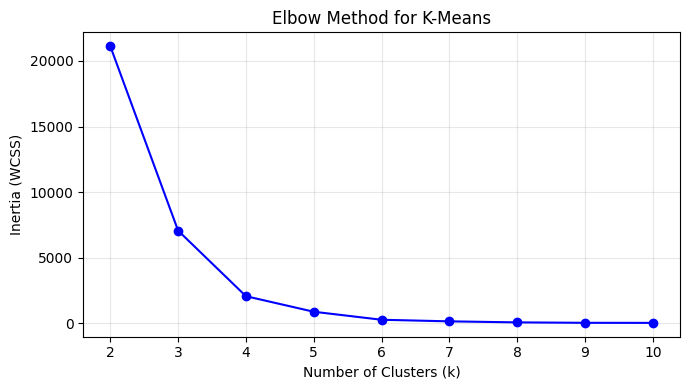

In [31]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(list(k_range), inertias, 'bo-')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (WCSS)')
ax.set_title('Elbow Method for K-Means')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('clustering_analysis.png', dpi=150)
plt.show()
